# Init

In [1]:
%load_ext autoreload
%autoreload 2

In [34]:
# Setup
import yaml
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

In [35]:
from src.feedbackqa.regression import FeedbackQARegressionRunner
from src.feedbackqa.diagnostics import collect_all_diagnostics, extract_diagnostic_table, overview

from src.general_analysis.engine import AnalysisEnvironment
from src.general_analysis.reliability import ReliabilityAnalyzer

from src.prompt_manager import PromptManager

from src.utils import interactive_dataframe_selector, interactive_regression_results_selector, interactive_plot_viewer

# Load data

In [4]:
env = AnalysisEnvironment(
    active_analysis='mcgill_qa_feedback', sandbox_mode=False)

# Load everything
# models_to_include: ['Qwen-Qwen3.5-4B', 'meta-llama-Llama-3.2-3B-Instruct']
final_df, og_df = env.load_data(use_cache=True, force_refresh=False)
pm, prompt_map = env.load_prompts()


prompt_hash_map = {
    key: item.metadata['description']
    for key, item in pm.suites.items()
}

Loading files for analysis McGill Feedback Analysis
⚡ Loading cached DataFrame from C:\Users\Wouter Barter\Documents\AI_thesis\results\MCGILL_QA_FEEDBACK\MCGILL_QA_FEEDBACK_analysis_ready.pkl...
PromptManager initialized with folder: ..\prompts\PromptSuites\MCGILL_QA_FEEDBACK
Scanning 6 suites from ..\prompts\PromptSuites\MCGILL_QA_FEEDBACK...
Loaded 6 PromptSuites


# Data Pre-processing

## Human readable cols

In [47]:
# Human readable prompt names

prompt_map_clean = {'f926cb88b5c8': 'Holistic Naive',
                    'f1ea5fbc4957': 'Holistic Informed', '83fb9645af53': 'Formative'}
final_df['prompt_name'] = final_df['prompt_id'].map(prompt_map_clean)

# Analysis group concatenation
final_df['analysis_group'] = final_df['model_name'] + \
    "_" + final_df['prompt_id']
final_df['analysis_group_full'] = final_df['model_name'] + "_" + \
    final_df['prompt_id'] + "_" + final_df['dimension_name']
final_df['analysis_group_named'] = final_df['model_name'] + \
    "_" + final_df['prompt_name'] + "_" + final_df['prompt_id']


# Human readable model col
model_map_clean = {
    'google/gemma-4-E2B-it': "Gemma 4",
    'meta-llama/Llama-3.2-3B-Instruct': "Llama 3.2",
    'Qwen/Qwen3-4B-Instruct-2507': "Qwen 3",
    'Qwen/Qwen3.5-4B': "Qwen 3.5"
}
final_df['model_name_clean'] = final_df['model_name'].map(model_map_clean)

# Human readable dimension col
dim_map_clean = {
    'qa_pair_topical_alignment': 'Topical Alignment',
    'qa_pair_information_coverage': 'Information Coverage',
    'qa_pair_topical_concentration': 'Topical Concentration',
    'qa_pair_communicative_clarity': 'Communicative Clarity',
    'qa_pair_overall_answer_quality': 'Overall Quality'
}
final_df['dimension_name_clean'] = final_df['dimension_name'].map(
    dim_map_clean)

final_df.loc[final_df['prompt_id'] == 'f1ea5fbc4957',
             'dimension_name_clean'] = 'Overall Quality (Informed)'
final_df.loc[final_df['prompt_id'] == 'f926cb88b5c8',
             'dimension_name_clean'] = 'Overall Quality (Naive)'


# Human readable analysis group/ experimental group
final_df['analysis_group_full_clean'] = final_df['model_name_clean'] + \
    ": " + final_df['dimension_name_clean'] + \
    "(" + final_df['prompt_name'] + ")"

## Extra features

In [48]:
# Input length
final_df['raw_input_length'] = final_df['question'].apply(
    len) + final_df['answer'].apply(len)

# Fill NaNs to prevent errors, split by whitespace, and count the list length
q_words = final_df['question'].fillna('').str.split().str.len()
a_words = final_df['answer'].fillna('').str.split().str.len()

final_df['question_word_count'] = q_words
final_df['answer_word_count'] = a_words
final_df['raw_input_word_count'] = q_words + a_words

final_df['log_raw_input_word_count'] = np.log1p(
    final_df['raw_input_word_count'])


final_df['length_bucket'] = pd.qcut(final_df['raw_input_word_count'], q=4,
                                    labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

final_df['answer_length_bucket'] = pd.qcut(final_df['answer_word_count'], q=4,
                                           labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

# Final EDA

## Mean, SD of human scores

In [49]:
pd.concat([og_df['score_1'], og_df['score_2']]).mean()

np.float64(2.4729178157749585)

In [50]:
pd.concat([og_df['score_1'], og_df['score_2']]).std()

np.float64(1.2463904008178122)

## Distribution of EV and Entropy

In [51]:
# from src.general_analysis.visualisations import plot_single_dimension_rating_distribution_by_model_pdf
# fig = plot_single_dimension_rating_distribution_by_model_pdf(
#     final_df=final_df,
#     dimension_name='Overall Quality (Naive)',
#     model_order=['Gemma 4', 'Llama 3.2', 'Qwen 3', 'Qwen 3.5'],
#     title=None,
#     rating_range=(1, 4),
#     save_path='../latex_thesis/figures/single_dimension_rating_regimes_feedbackqa.pdf'
# )

In [52]:
from src.general_analysis.tables import rating_entropy_distribution
mean_entr_distribution = rating_entropy_distribution(final_df)


print(mean_entr_distribution.to_latex(
    column_format='lcc',
    caption='Scale Utilization and Entropy Calibration by Model Architecture.',
    label='tab:scale_utilization_barter',
    escape=False
))

\begin{table}
\caption{Scale Utilization and Entropy Calibration by Model Architecture.}
\label{tab:scale_utilization_barter}
\begin{tabular}{lcc}
\toprule
 & Rating: Mean (SD) & Entropy: Mean (SD) \\
Model &  &  \\
\midrule
Gemma 4 & 2.54 (0.74) & 0.13 (0.18) \\
Llama 3.2 & 2.72 (0.77) & 0.72 (0.23) \\
Qwen 3 & 2.95 (0.88) & 0.12 (0.16) \\
Qwen 3.5 & 2.66 (0.67) & 0.73 (0.15) \\
\bottomrule
\end{tabular}
\end{table}



In [53]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

In [54]:
plot_order = list(dim_map_clean.values())


fig = plot_rating_distributions_by_architecture(
    final_df=final_df,
    plot_order=plot_order,
    dim_map_clean=dim_map_clean,
    score_col='mean_rating',
    rating_range=(1, 4),
    save_path='../latex_thesis/figures/feedbackqa_rating_distributions.pdf',
    show=False
)

## Verbosity bias

In [55]:
from src.general_analysis.tables import verbosity_bias_table, summarize_verbosity_bias

sections = {
    'Total Input': 'raw_input_word_count'}

verbosity_df = verbosity_bias_table(
    df=final_df,
    sections=sections,
    min_abs_d=0  # only medium or larger effects
)
# verbosity_df

verbosity_summary = summarize_verbosity_bias(
    bias_df=verbosity_df,
    model_col="Model",
    abs_d_col="Absolute Cohen's d",
    combine_medium_large=False
)

print(
    verbosity_summary.to_latex(
        index=False,
        escape=False,
        column_format="lccccccc",
        caption="Summary of FeedbackQA Verbosity-Bias Diagnostics",
        label="tab:verbosity_bias_feedbackqa"
    )
)

\begin{table}
\caption{Summary of FeedbackQA Verbosity-Bias Diagnostics}
\label{tab:verbosity_bias_feedbackqa}
\begin{tabular}{lccccccc}
\toprule
Model & Mean $|d|$ & Max $|d|$ & N & Negligible & Small & Medium & Large \\
\midrule
Gemma 4 & 0.16 & 0.20 & 6 & 5 & 1 & 0 & 0 \\
Llama 3.2 & 0.57 & 0.62 & 6 & 0 & 0 & 6 & 0 \\
Qwen 3 & 0.15 & 0.25 & 6 & 4 & 2 & 0 & 0 \\
Qwen 3.5 & 0.11 & 0.25 & 6 & 5 & 1 & 0 & 0 \\
\bottomrule
\end{tabular}
\end{table}



## VIF

In [56]:
final_df[final_df['prompt_name'] == 'Formative']

,question,passage,feedback,rating,domain,source_file,review_1,explanation_1,review_2,explanation_2,...,model_name_clean,dimension_name_clean,analysis_group_full_clean,raw_input_length,question_word_count,answer_word_count,raw_input_word_count,log_raw_input_word_count,length_bucket,answer_length_bucket
0,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Topical Alignment,Gemma 4: Topical Alignment(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
1,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Information Coverage,Gemma 4: Information Coverage(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
2,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Topical Concentration,Gemma 4: Topical Concentration(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
3,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Gemma 4,Communicative Clarity,Gemma 4: Communicative Clarity(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
6,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",...,Llama 3.2,Topical Alignment,Llama 3.2: Topical Alignment(Formative),1116,8,145,153,5.036953,3. Medium-Long,3. Medium-Long
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217647,Why do we need to stay active during lockdown ...,"{'passage_id': 44, 'reference': {'page_title':...",[This is a direct answer to the question. this...,"[Excellent, Could be Improved, Bad]",WHO,test,Excellent,This is a direct answer to the question. this ...,Could be Improved,This answer talks more about the benefits of p...,...,Qwen 3,Communicative Clarity,Qwen 3: Communicative Clarity(Formative),860,11,121,132,4.890349,3. Medium-Long,3. Medium-Long
217650,Why do we need to stay active during lockdown ...,"{'passage_id': 44, 'reference': {'page_title':...",[This is a direct answer to the question. this...,"[Excellent, Could be Improved, Bad]",WHO,test,Excellent,This is a direct answer to the question. this ...,Could be Improved,This answer talks more about the benefits of p...,...,Qwen 3.5,Topical Alignment,Qwen 3.5: Topical Alignment(Formative),860,11,121,132,4.890349,3. Medium-Long,3. Medium-Long
217651,Why do we need to stay active during lockdown ...,"{'passage_id': 44, 'reference': {'page_title':...",[This is a direct answer to the question. this...,"[Excellent, Could be Improved, Bad]",WHO,test,Excellent,This is a direct answer to the question. this ...,Could be Improved,This answer talks more about the benefits of p...,...,Qwen 3.5,Information Coverage,Qwen 3.5: Information Coverage(Formative),860,11,121,132,4.890349,3. Medium-Long,3. Medium-Long
217652,Wh

In [57]:
# Predicting ratings (original behaviour, entropy now actually included)
runner_mean = FeedbackQARegressionRunner(
    experimental_groups=['model_name_clean', 'prompt_id'],
    prompt_hash_map=prompt_map_clean,
    llm_prediction_col='mean_rating',
    covariates=['log_raw_input_word_count'],
    include_entropy=False,       # now adds entropy_* cols to iv_cols
    mode="rating",
    model_col='model_name_clean'
)

vif_df = runner_mean.compute_vifs(
    df=final_df[final_df['prompt_name'] == 'Formative'])

In [58]:
from src.general_analysis.diagnostics import compact_vif_threshold_summary

vif_table = compact_vif_threshold_summary(vif_df).copy()

# Optional: make labels thesis-clean
vif_table["Group"] = (
    vif_table["Group"]
    .str.replace("_", " ", regex=False)
)

latex_vif_table = vif_table.to_latex(
    index=False,
    column_format="lccrrl",
    caption="VIF Diagnostics for FeedbackQA Formative Specifications",
    label="tab:VIF_feedbackqa",
    escape=False
)

print(latex_vif_table)

\begin{table}
\caption{VIF Diagnostics for FeedbackQA Formative Specifications}
\label{tab:VIF_feedbackqa}
\begin{tabular}{lccrrl}
\toprule
Group & Max VIF & Mean VIF & N VIF > 5 & N VIF > 10 & Multicollinearity \\
\midrule
Gemma 4 Formative & 6.75 & 4.46 & 3 & 0 & Moderate \\
Llama 3.2 Formative & 16.93 & 9.43 & 4 & 2 & Substantial \\
Qwen 3.5 Formative & 11.39 & 6.88 & 4 & 1 & Substantial \\
Qwen 3 Formative & 9.38 & 6.86 & 4 & 0 & Moderate \\
\bottomrule
\end{tabular}
\end{table}



# General EDA

In [59]:
plot_order = list(dim_map_clean.values())


prompt_order = ['Holistic Naive', 'Holistic Informed', 'Formative']

## Distribrution across rating scale

In [60]:
combined_scores = pd.concat(
    [og_df['score_1'], og_df['score_2']], ignore_index=True)

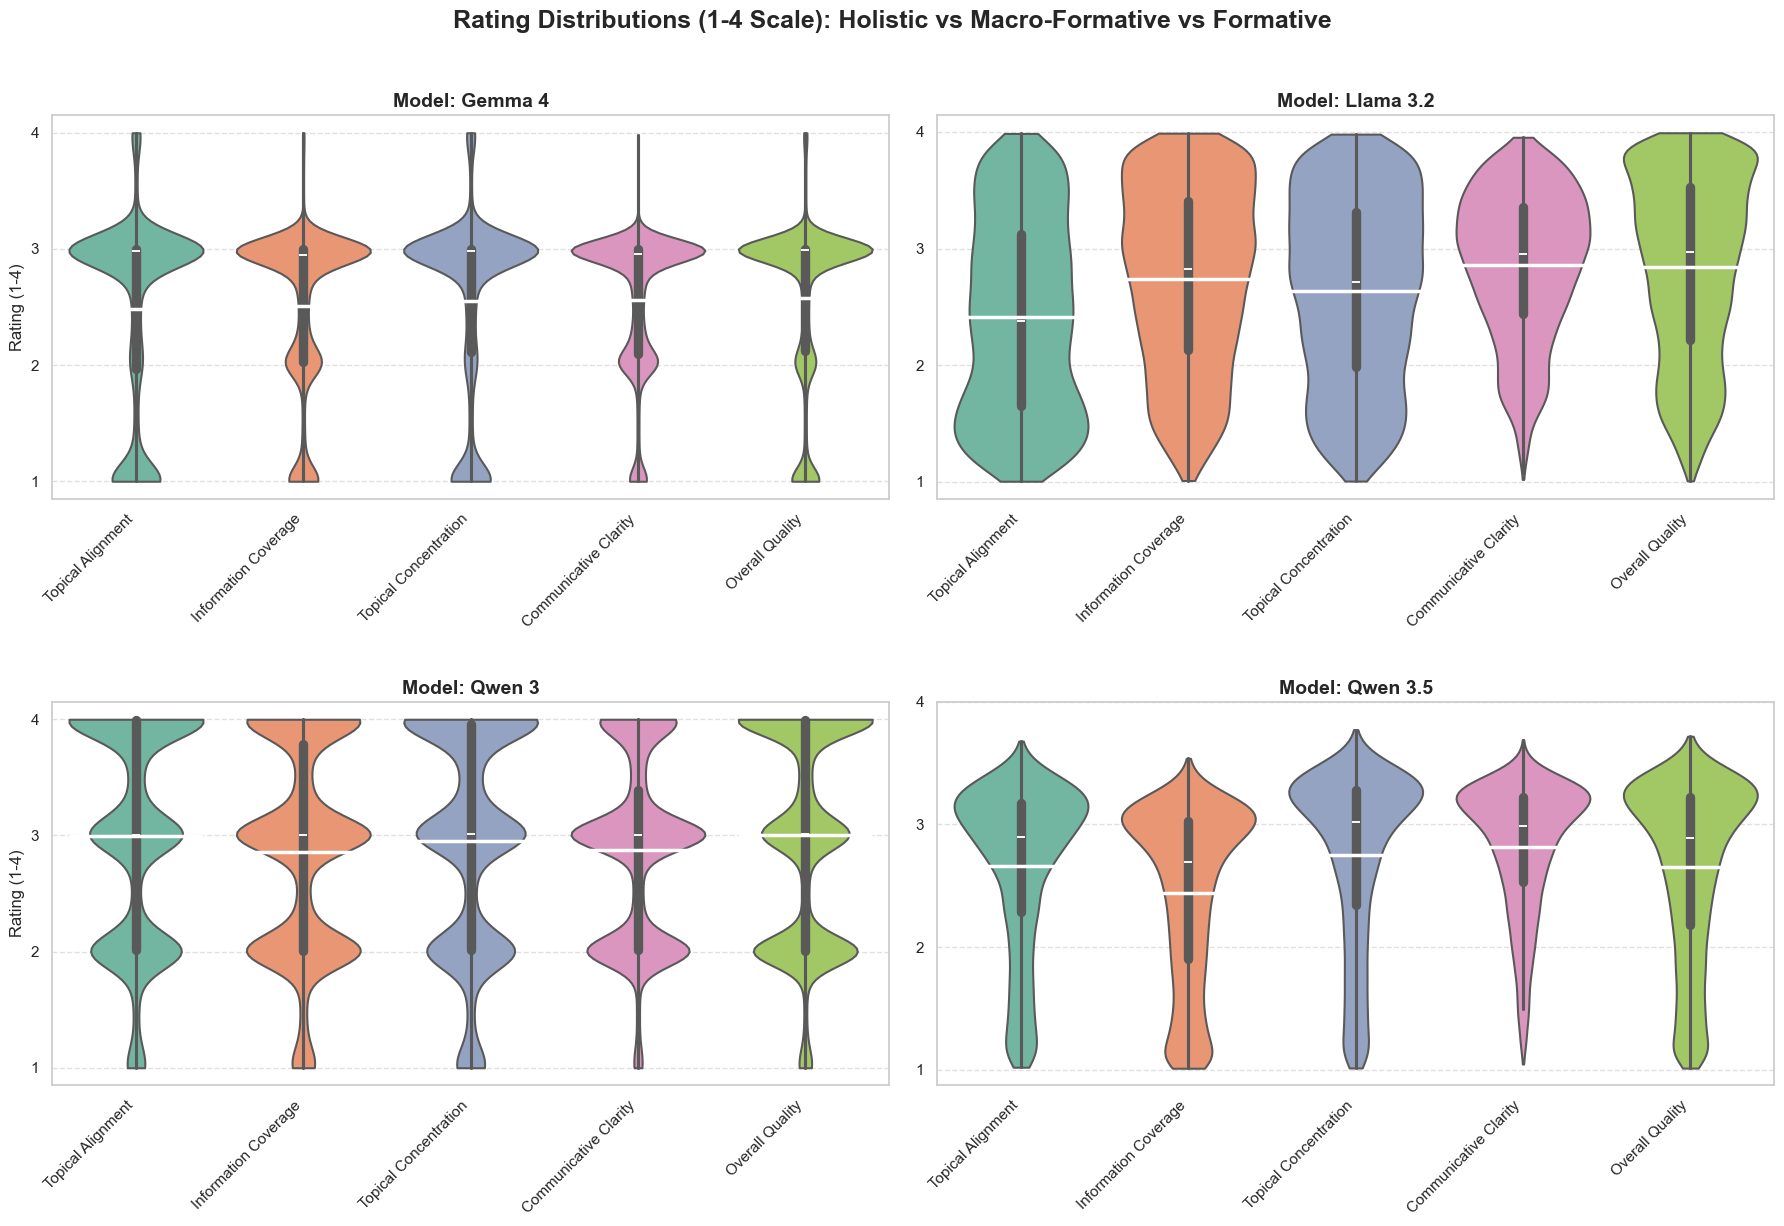

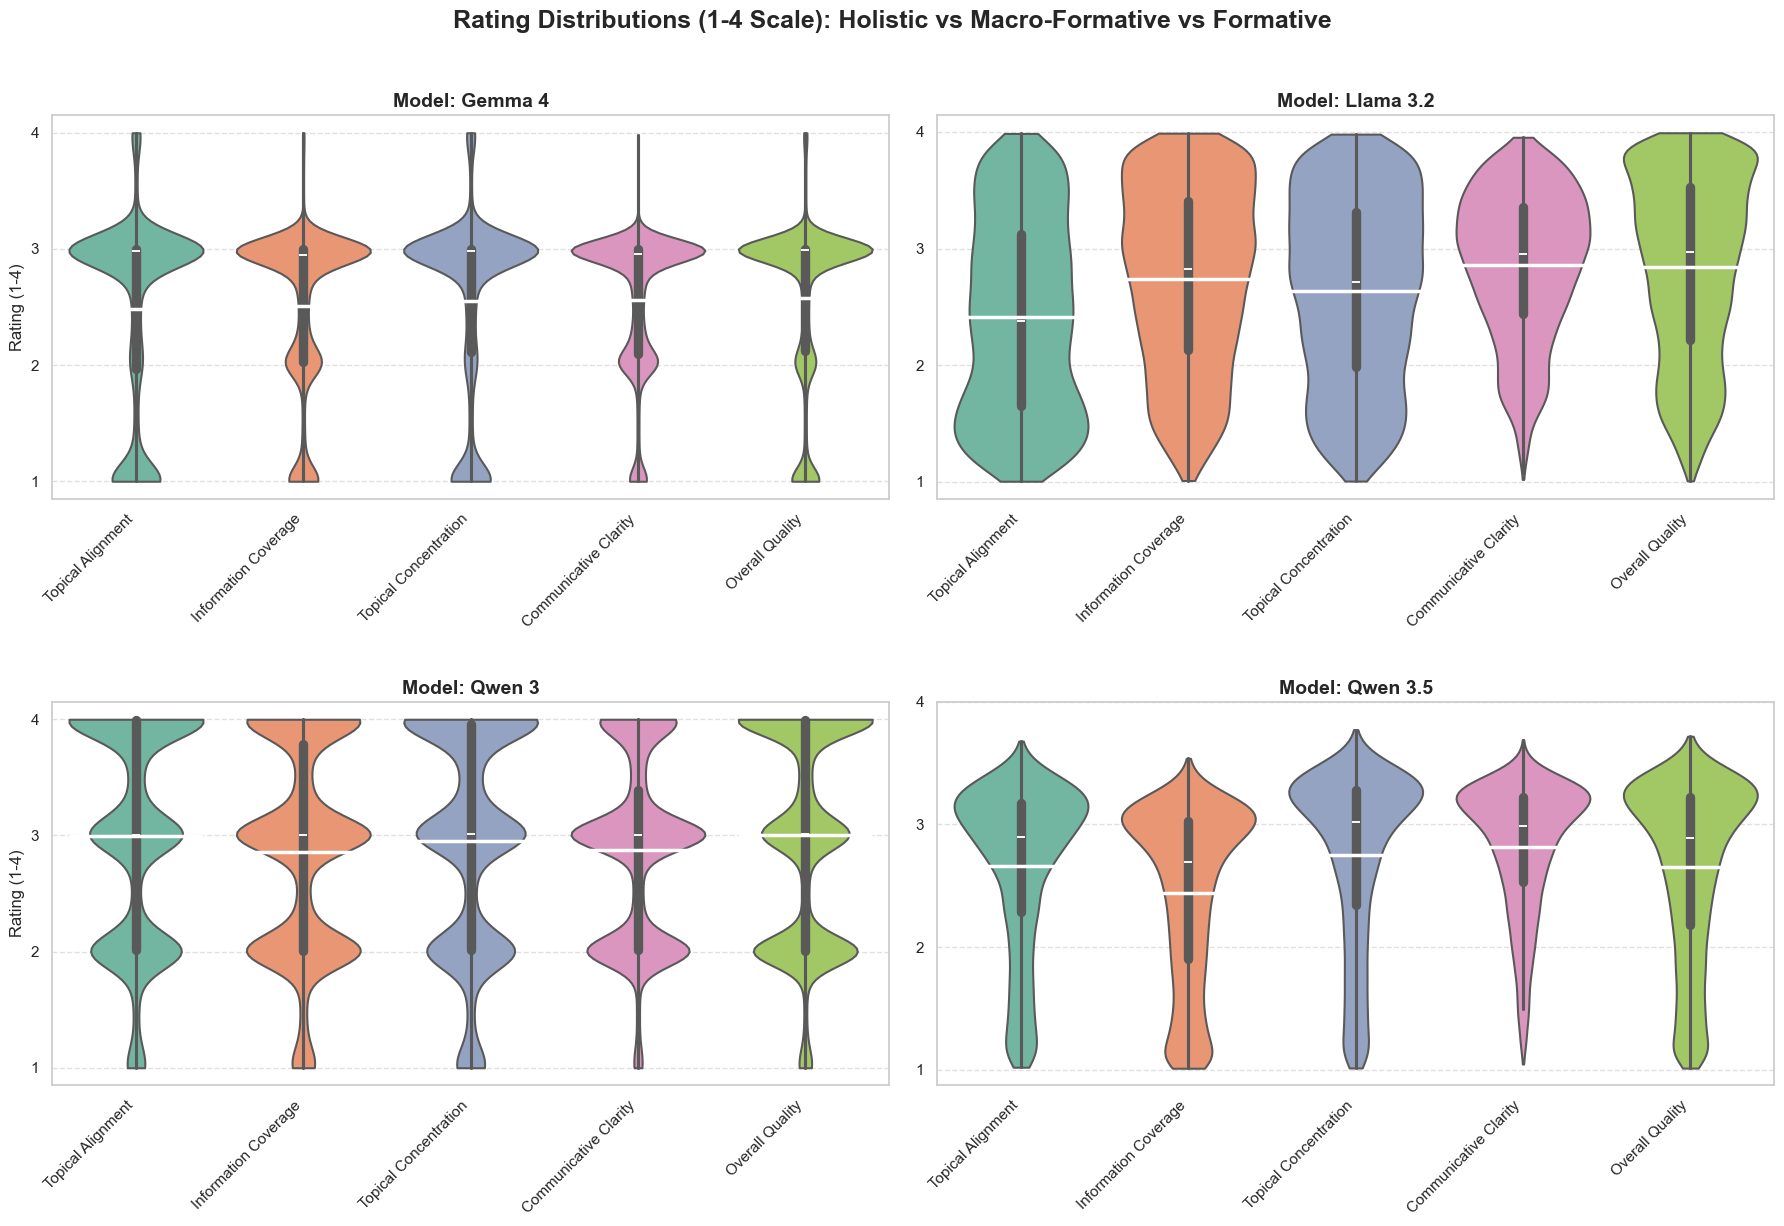

In [61]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (1, 4)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, dim_map_clean=dim_map_clean, score_col='mean_rating', rating_range=rating_range)

## Correlation matrix

In [62]:
# Pivot the table so each dimension is a column, and each row is a Q&A pair
pivot_df = final_df.pivot(
    index='input_id',  # Or whatever your document ID column is named
    columns='analysis_group_full_clean',
    values='normalized_entropy'
)

# Now calculate the correlation matrix
corr_matrix = pivot_df.corr()

display(corr_matrix)

analysis_group_full_clean,Gemma 4: Communicative Clarity(Formative),Gemma 4: Information Coverage(Formative),Gemma 4: Overall Quality (Informed)(Holistic Informed),Gemma 4: Overall Quality (Naive)(Holistic Naive),Gemma 4: Topical Alignment(Formative),Gemma 4: Topical Concentration(Formative),Llama 3.2: Communicative Clarity(Formative),Llama 3.2: Information Coverage(Formative),Llama 3.2: Overall Quality (Informed)(Holistic Informed),Llama 3.2: Overall Quality (Naive)(Holistic Naive),...,Qwen 3.5: Overall Quality (Informed)(Holistic Informed),Qwen 3.5: Overall Quality (Naive)(Holistic Naive),Qwen 3.5: Topical Alignment(Formative),Qwen 3.5: Topical Concentration(Formative),Qwen 3: Communicative Clarity(Formative),Qwen 3: Information Coverage(Formative),Qwen 3: Overall Quality (Informed)(Holistic Informed),Qwen 3: Overall Quality (Naive)(Holistic Naive),Qwen 3: Topical Alignment(Formative),Qwen 3: Topical Concentration(Formative)
analysis_group_full_clean,,,,,,,,,,,,,,,,,,,,,
Gemma 4: Communicative Clarity(Formative),1.000000,0.307876,0.347015,0.373071,0.197968,0.219245,0.084731,0.038861,0.045750,0.092717,...,0.152407,0.134737,0.108478,0.175781,-0.007774,0.036429,0.064948,0.048245,0.068541,0.051891
Gemma 4: Information Coverage(Formative),0.307876,1.000000,0.594067,0.489466,0.307807,0.331402,0.141967,0.148067,0.149399,0.179670,...,0.217625,0.205546,0.170913,0.209052,-0.032908,0.049346,0.080247,0.079434,0.072166,0.049410
Gemma 4: Overall Quality (Informed)(Holistic Informed),0.347015,0.594067,1.000000,0.660006,0.395294,0.413874,0.084286,0.067468,0.072818,0.107483,...,0.197311,0.179321,0.161652,0.211425,-0.043779,0.019464,0.037069,0.027201,0.049177,0.030716
Gemma 4: Overall Quality (Naive)(Holistic Naive),0.373071,0.489466,0.660006,1.000000,0.339882,0.374484,0.064464,0.036185,0.045997,0.086076,...,0.155207,0.134189,0.118205,0.172768,-0.037268,0.010833,0.015611,0.004048,0.043895,0.025711
Gemma 4: Topical Alignment(Formative),0.197968,0.307807,0.395294,0.339882,1.000000,0.599280,0.068098,0.073033,0.078697,0.097482,...,0.207332,0.195077,0.209328,0.216388,-0.031806,0.020580,0.029279,0.024445,0.032743,0.016843
Gemma 4: Topical Concentration(Formative),0.219245,0.331402,0.413874,0.374484,0.599280,1.000000,0.066158,0.061766,0.069648,0.094759,...,0.184493,0.164287,0.185019,0.216162,-0.026454,0.023371,0.033603,0.019983,0.035120,0.018473
Llama 3.2: Communicative Clarity(Formative),0.084731,0.141967,0.084286,0.064464,0.068098,0.066158,1.000000,0.850453,0.837761,0.857458,...,0.194074,0.209445,0.168289,0.142153,0.004297,0.087619,0.119669,0.118471,0.095762,0.070672
Llama 3.2: Information Coverage(Formative),0.038861,0.148067,0.067468,0.036185,0.073033,0.061766,0.850453,1.000000,0.924226,0.906543,...,0.226414,0.250064,0.207559,0.165553,-0.006882,0.107809,0.132553,0.134696,0.117625,0.080515
Llama 3.2: Overall Quality (Informed)(Holistic Informed),0.045750,0.149399,0.072818,0.045997,0.078697,0.069648,0.837761,0.924226,1.000000,0.918174,...,0.210830,0.228007,0.194071,0.159231,-0.014348,0.094454,0.127351,0.124973,0.113378,0.084306


## Verbosity bias (relationship between input length and rating)

### Ceiling effect

In [63]:
from src.general_analysis.visualisations import plot_verbosity_grid

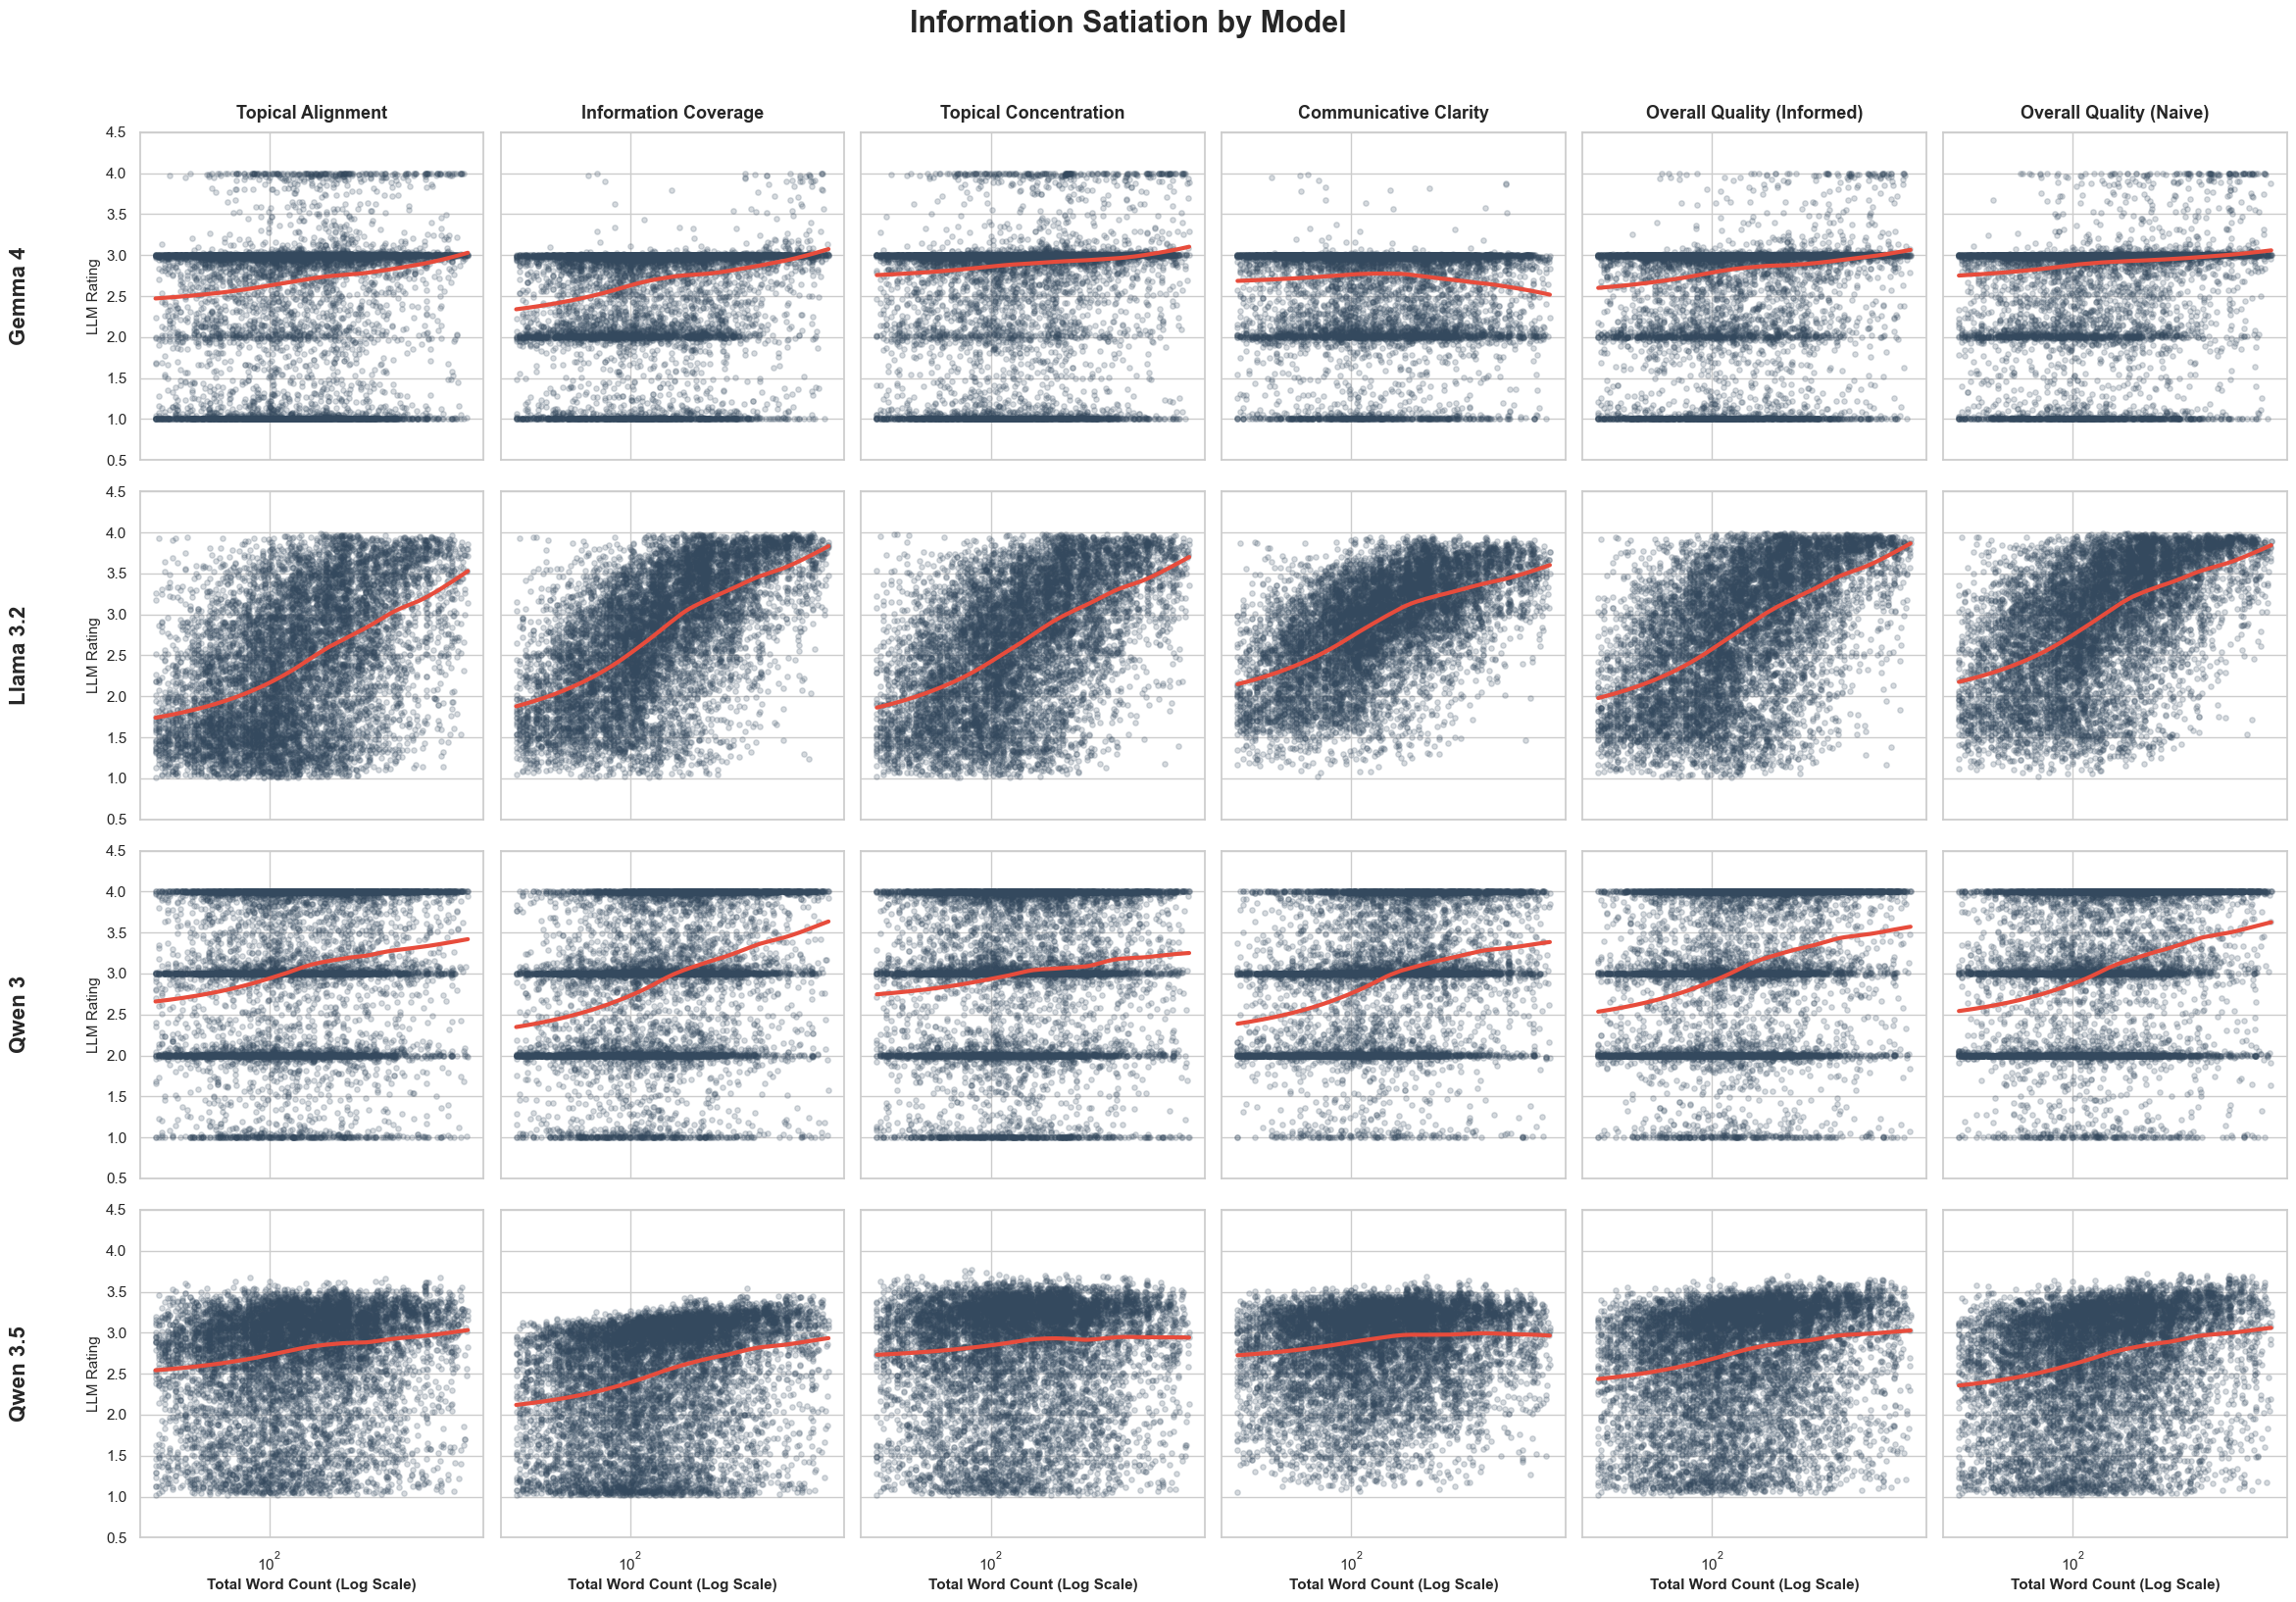

In [64]:
models = final_df['model_name_clean'].unique()
dimensions = final_df['dimension_name_clean'].unique()
plot_verbosity_grid(final_df,
                    models=models,
                    dimensions=dimensions,
                    model_col='model_name_clean',
                    dim_col='dimension_name_clean',
                    x_col='raw_input_word_count',
                    y_col='mean_rating',
                    lower_truncate_pct=0.02,
                    upper_truncate_pct=0.98,
                    y_min=0.5, y_max=4.5)

C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:334: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=res_df, x='Text Section', y='Absolute Cohen\'s d', hue='Model',


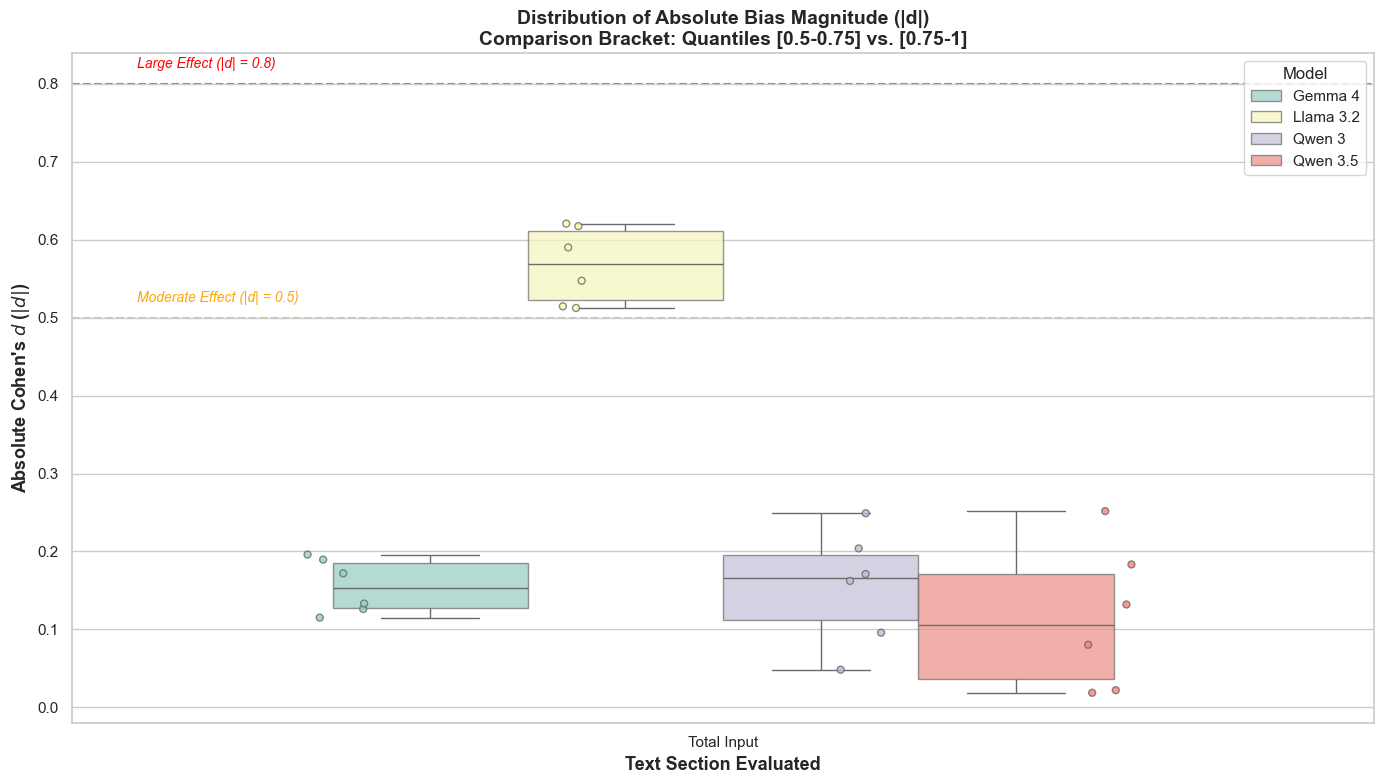

In [65]:
from src.general_analysis.visualisations import plot_absolute_bias_spread

sections = {
    'Total Input': 'raw_input_word_count'}

res_df_upperquart = plot_absolute_bias_spread(final_df, sections, p_lower=[
    0.5, 0.75], p_upper=[0.75, 1])

## Entropy

### Distribution

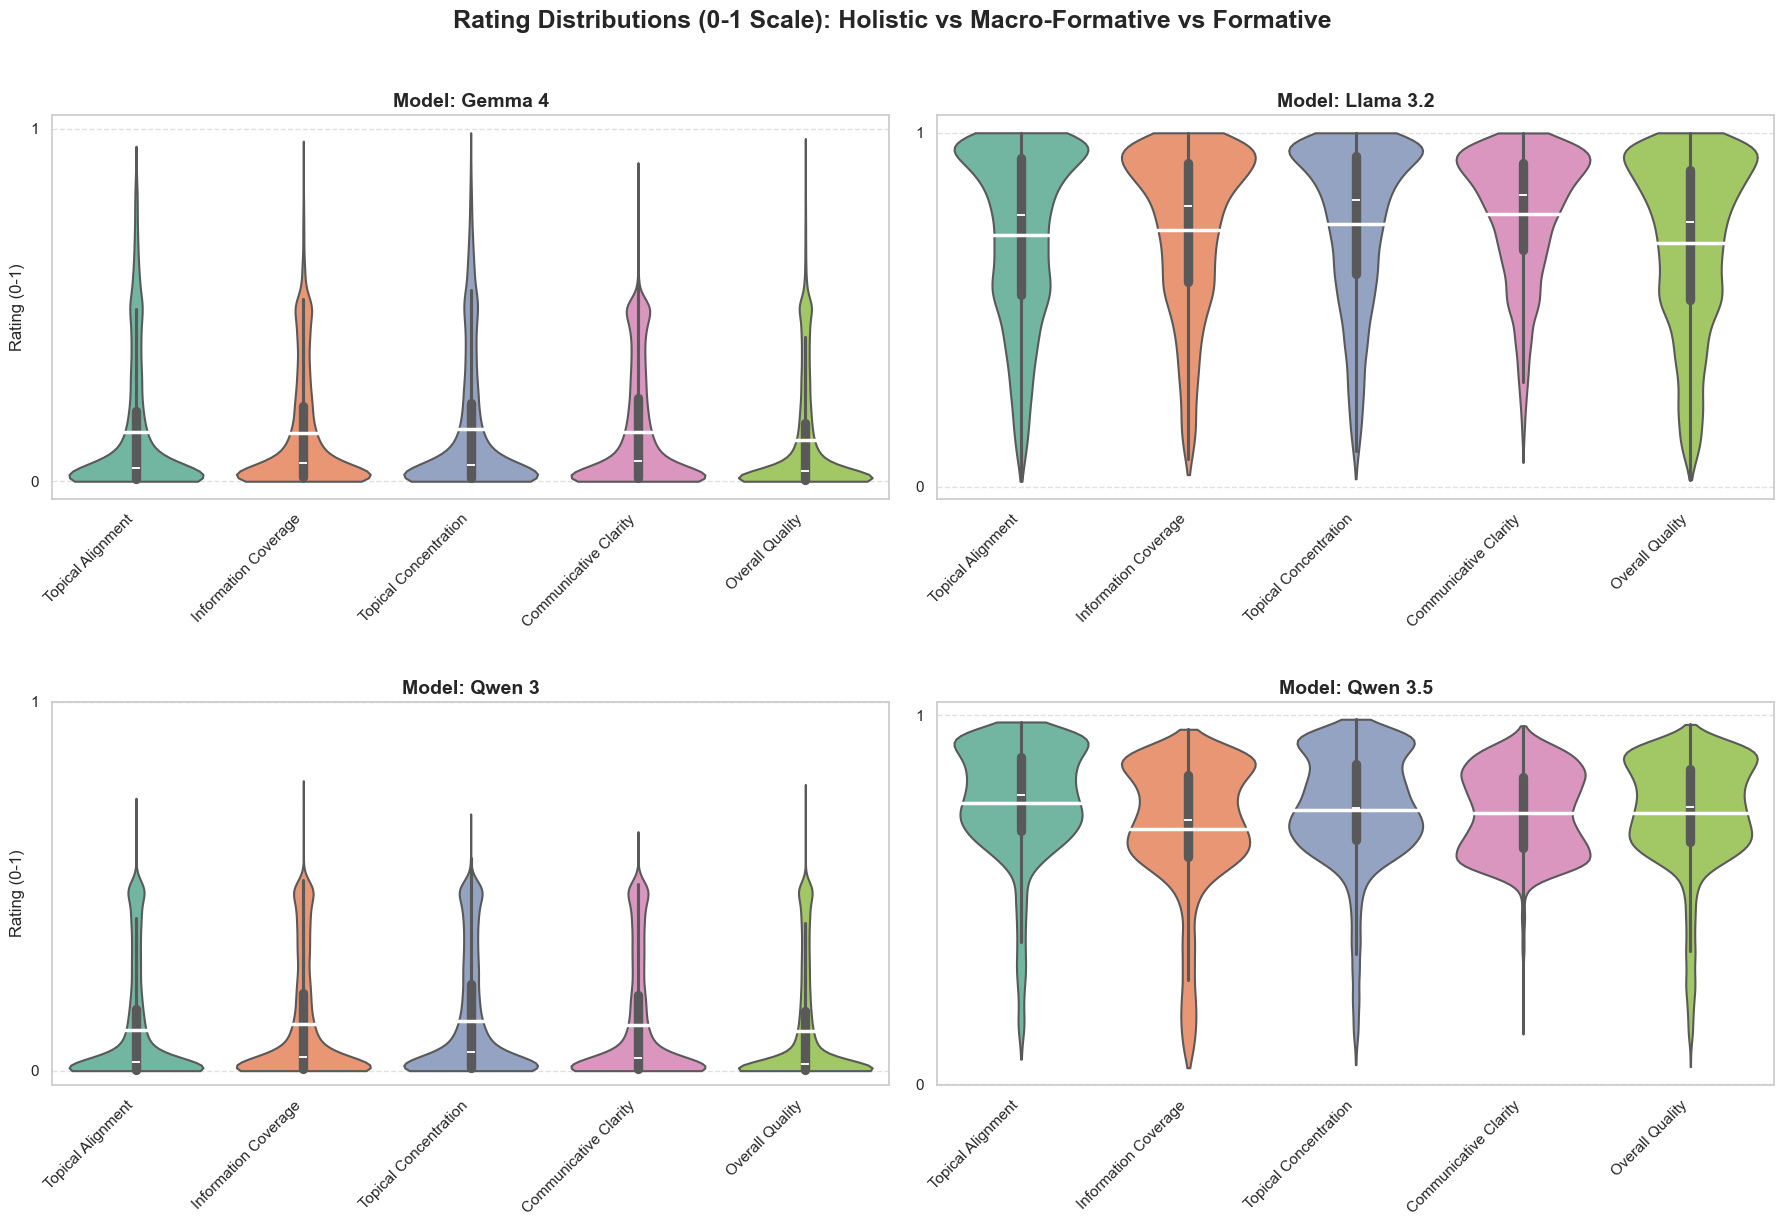

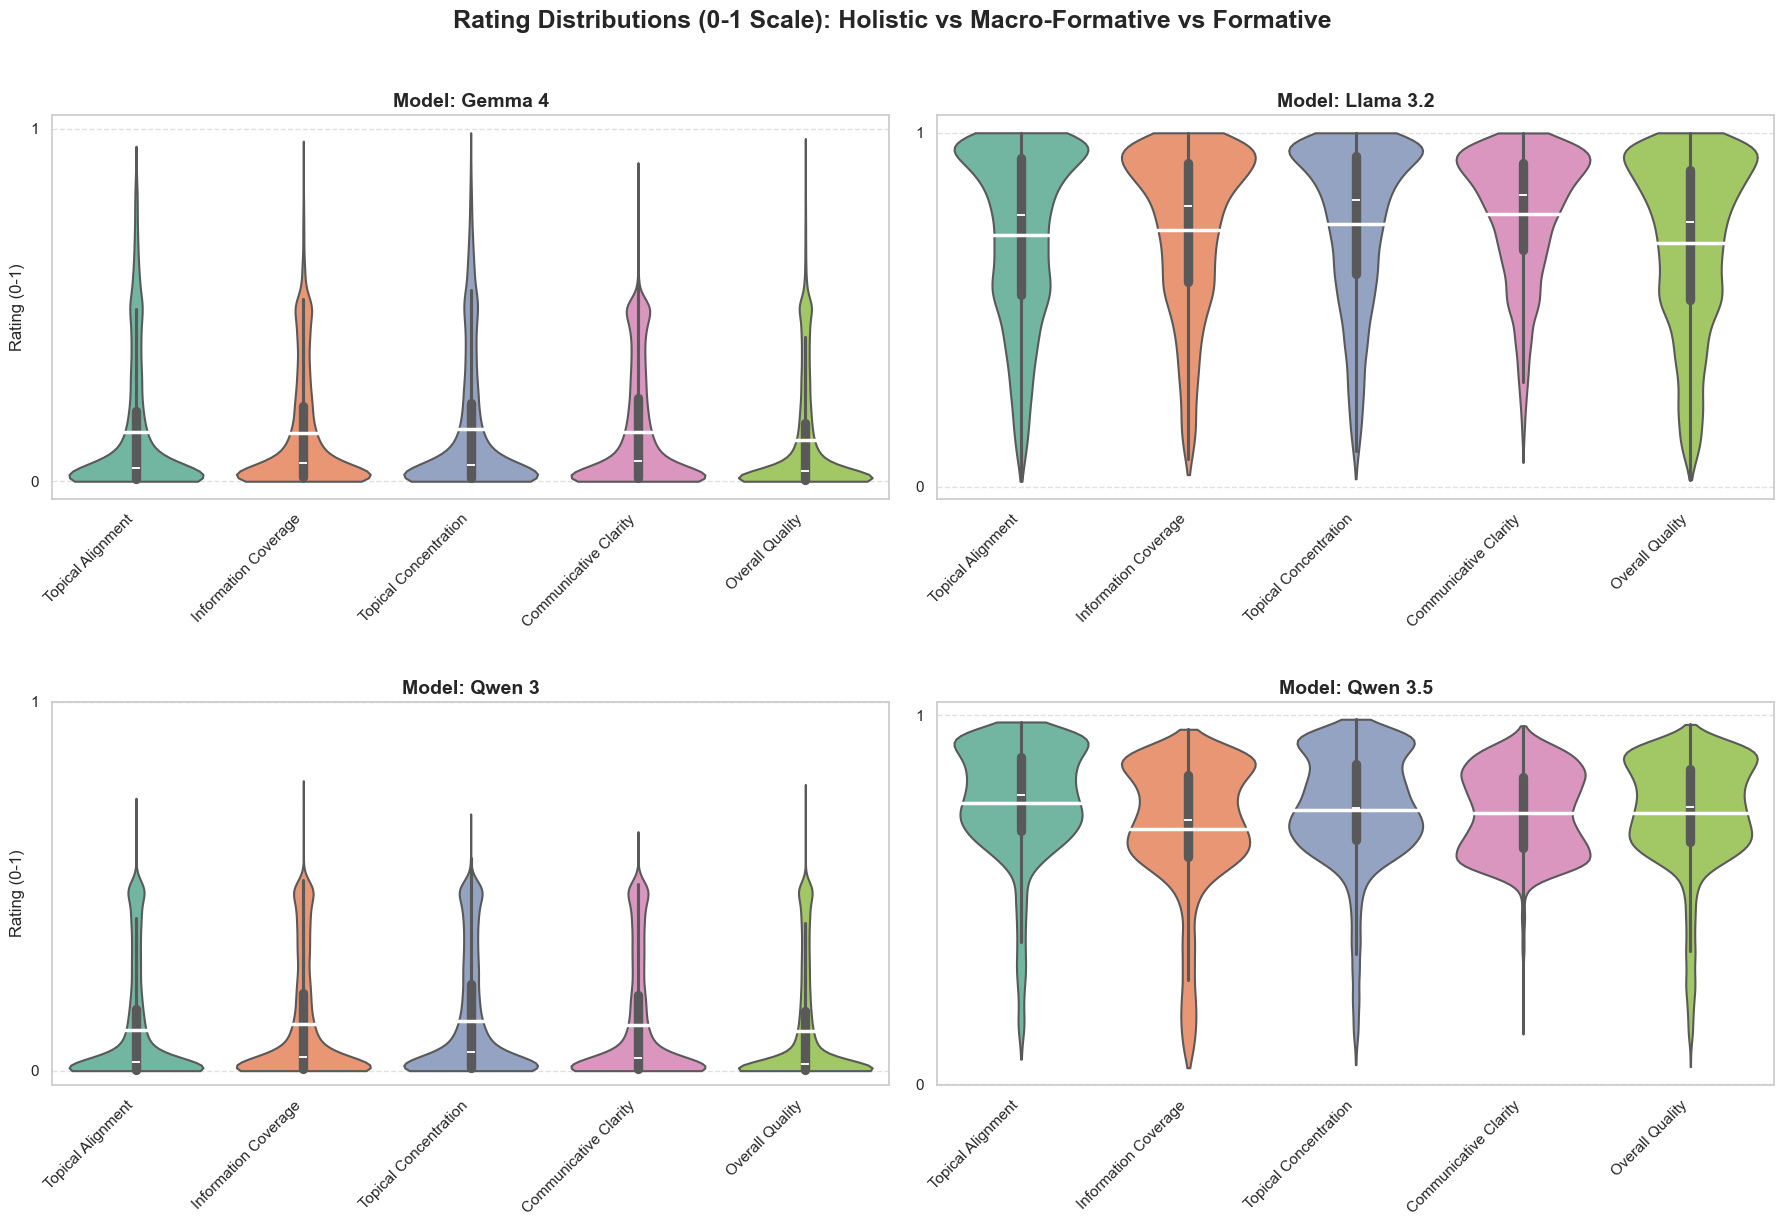

In [66]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (0, 1)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, score_col='normalized_entropy', rating_range=(0, 1), dim_map_clean=dim_map_clean)

##  Inter-rater reliability

In [67]:
analyzer = ReliabilityAnalyzer(final_df, group_cols=[
                               'model_name', 'prompt_id', 'dimension_name'], llm_rating_col='mean_rating')
analyzer.compute_reliability_gap(metric='spearman')

,model_name,prompt_id,dimension_name,metric_type,spearman_gap,spearman_hh,spearman_llm_avg
1,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_information_coverage,Spearman,-0.031385,0.540923,0.572308
7,Qwen/Qwen3.5-4B,83fb9645af53,qa_pair_information_coverage,Spearman,-0.030364,0.540923,0.571287
4,Qwen/Qwen3-4B-Instruct-2507,f1ea5fbc4957,qa_pair_overall_answer_quality,Spearman,-0.026085,0.540923,0.567008
2,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_topical_alignment,Spearman,-0.022182,0.540923,0.563105
5,Qwen/Qwen3-4B-Instruct-2507,f926cb88b5c8,qa_pair_overall_answer_quality,Spearman,-0.019690,0.540923,0.560612
11,Qwen/Qwen3.5-4B,f926cb88b5c8,qa_pair_overall_answer_quality,Spearman,-0.015557,0.540923,0.556480
10,Qwen/Qwen3.5-4B,f1ea5fbc4957,qa_pair_overall_answer_quality,Spearman,-0.012948,0.540923,0.553871
3,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_topical_concentration,Spearman,0.000002,0.540923,0.540921
8,Qwen/Qwen3.5-4B,83fb9645af53,qa_pair_topical_alignment,Spearman,0.002026,0.540923,0.538897
0,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_communicative_clarity,Spearman,0.005356,0.540923,0.535567


Because the permutation tests are based on paired out-of-fold predictions, even small improvements can be statistically significant. We therefore interpret statistical significance together with the absolute change in Spearman's $\rho$. The formative condition improves rank-order alignment relative to the naive baseline across all model families, but the magnitude of the improvement is bounded by the relatively high performance of the holistic baselines and the moderate human-human agreement in the dataset.

The FeedbackQA results should be interpreted in light of the human-human reference. The two human annotations correlate at approximately $\rho = 0.54$, while the Qwen holistic baselines already reach a similar level of alignment with the human annotations. This leaves limited headroom for the formative specifications to improve the global correlation metrics. The relatively small incremental gains from formative decomposition therefore do not necessarily imply that decomposition is uninformative; rather, the task provides a noisy and partially saturated benchmark.

A second explanation is the high collinearity among the FeedbackQA formative dimensions. Although Topical Alignment, Information Coverage, Topical Concentration, and Communicative Clarity are conceptually distinct, the dataset often presents cases where these dimensions fail together. In particular, topically mismatched answers are likely to receive low scores across several criteria. As a result, the formative measurements contain limited unique variance beyond the holistic score, reducing the potential gain from decomposition.

This differs from the Barter Deals setting, where Deal Attractiveness is more clearly shaped by opposing forces. A Deal may offer high reward but impose high workload, or have a prestigious brand but a weak call-to-action. In such cases, decomposition is more likely to reveal distinct predictive signals that are obscured by a holistic score.


Overall, the FeedbackQA results provide evidence for the formative measurement framework, but the effect size is modest. The formative condition improves rank-order alignment relative to the naive baseline across model families, yet the gains are constrained by two features of the task. First, the strongest holistic baselines already approach the human-human reference level, leaving limited headroom for improvement. Second, the formative dimensions are highly correlated in this dataset, limiting the amount of unique variance that decomposition can recover. The entropy extensions produce statistically detectable but small incremental gains, suggesting that most of the out-of-sample alignment is captured by the EV measurements.

The fact that some LLM specifications reach human-human levels of rank correlation indicates that they capture a substantial portion of the stable document-level quality signal. However, human-human agreement reflects the reliability of a single annotation, not a strict performance ceiling. Moreover, aggregate correlations can obscure localized failure modes, especially cases where human annotators apply near-veto penalties for topical mismatch.

# Regression

## Mean

In [68]:
# Predicting ratings (original behaviour, entropy now actually included)
runner_mean = FeedbackQARegressionRunner(
    experimental_groups=['model_name_clean', 'prompt_id'],
    prompt_hash_map=prompt_map_clean,
    llm_prediction_col='mean_rating',
    covariates=['log_raw_input_word_count'],
    include_entropy=False,       # now adds entropy_* cols to iv_cols
    mode="rating",
    model_col='model_name_clean'
)
runner_mean.run_regression(final_df)

diagnostics_mean = collect_all_diagnostics(runner_mean)
ov_mean = overview(diagnostics_mean)

✓ Gemma 4_Formative | n=18126 | AIC=54693.12
✓ Gemma 4_Holistic Informed | n=18126 | AIC=55241.29
✓ Gemma 4_Holistic Naive | n=18126 | AIC=55519.76
✓ Llama 3.2_Formative | n=18126 | AIC=55812.71
✓ Llama 3.2_Holistic Informed | n=18126 | AIC=56306.91
✓ Llama 3.2_Holistic Naive | n=18126 | AIC=56321.66
✓ Qwen 3_Formative | n=18126 | AIC=52091.79
✓ Qwen 3_Holistic Informed | n=18126 | AIC=52808.60
✓ Qwen 3_Holistic Naive | n=18126 | AIC=52998.24
✓ Qwen 3.5_Formative | n=18126 | AIC=52117.71
✓ Qwen 3.5_Holistic Informed | n=18126 | AIC=52658.78
✓ Qwen 3.5_Holistic Naive | n=18126 | AIC=52613.78


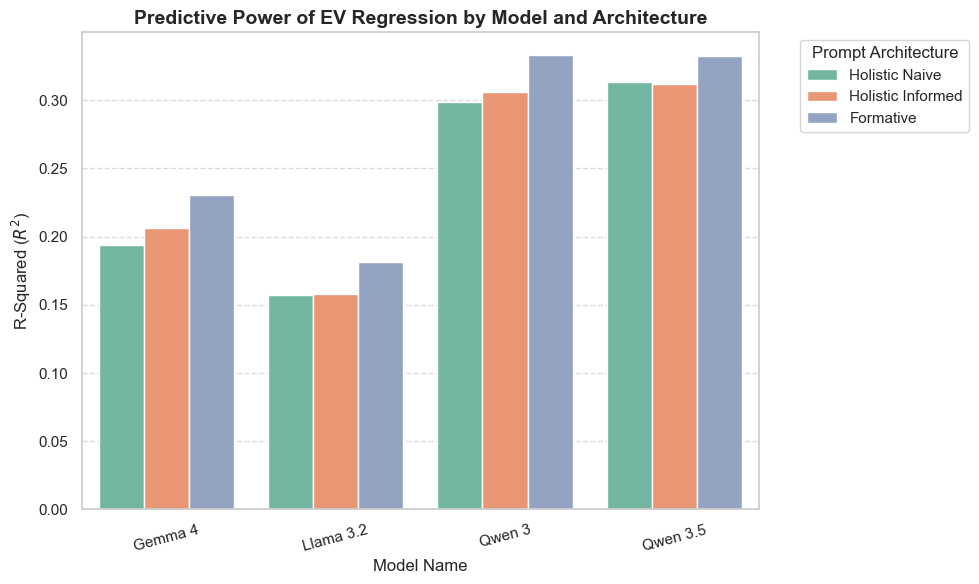

<Axes: title={'center': 'Predictive Power of EV Regression by Model and Architecture'}, xlabel='Model Name', ylabel='R-Squared ($R^2$)'>

In [69]:
from src.feedbackqa.visualisations import plot_ev_regression_r2

df_results = ov_mean['metrics']
plot_ev_regression_r2(df_results)

In [108]:
interactive_dataframe_selector(ov_mean)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('metrics', 'coefficients', 'vif'…

,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number
0,Gemma 4_Formative,18126.0,0.230169,0.229956,NaN,54693.121461,54739.952077,-27340.560731,63.793078,6.213968
1,Gemma 4_Holistic Informed,18126.0,0.206269,0.206181,NaN,55241.290100,55264.705408,-27617.645050,42.147221,1.225243
2,Gemma 4_Holistic Naive,18126.0,0.193981,0.193892,NaN,55519.757047,55543.172355,-27756.878523,42.836553,1.237154
3,Llama 3.2_Formative,18126.0,0.181119,0.180893,NaN,55812.709823,55859.540439,-27900.354912,65.984041,10.119759
4,Llama 3.2_Holistic Informed,18126.0,0.158207,0.158114,NaN,56306.907974,56330.323282,-28150.453987,41.760155,1.872585
5,Llama 3.2_Holistic Naive,18126.0,0.157522,0.157429,NaN,56321.658750,56345.074057,-28157.829375,41.992996,1.863292
6,Qwen 3_Formative,18126.0,0.333088,0.332904,NaN,52091.794980,52138.625596,-26039.897490,63.472128,7.623504
7,Qwen 3_Holistic Informed,18126.0,0.305957,0.305880,NaN,52808.598235,52832.013543,-26401.299117,43.063066,1.338482
8,Qwen 3_Holistic Naive,18126.0,0.298657,0.298580,NaN,52998.240000,53021.655308,-26496.120000,42.970828,1.353520
9,Qwen 3.5_Formative,18126.0,0.332134,0.331950,NaN,52117.708115,52164.538731,-26052.854057,76.257976,7.935938


In [109]:
interactive_regression_results_selector(runner_mean.results)

Dropdown(description='Select option:', index=9, layout=Layout(width='400px'), options=('Gemma 4_Formative', 'G…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     2139.
Date:                Fri, 03 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:54:56   Log-Likelihood:                -26053.
No. Observations:               18126   AIC:                         5.212e+04
Df Residuals:                   18120   BIC:                         5.216e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                        -0.5293      0.074     -7.128      0.000      -0.675      -0.384
mean_rating_qa_pair_communicative_clarity    -0.0023      0.036     -0.063      0.950      -0.074       0.069
mean_rating_qa_pair_information_coverage      0.9159      0.035     26.071      0.000       0.847       0.985
mean_rating_qa_pair_topical_alignment         0.3674      0.039      9.493      0.000       0.292       0.443
mean_rating_qa_pair_topical_concentration    -0.2883      0.044     -6.565      0.000      -0.374      -0.202
log_raw_input_word_count                      0.1201      0.015      8.229      0.000       0.092       0.149
==============================================================================
Omnibus:                      455.655   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              293.120
Skew:                          -0.182   Prob(JB):                     2.24e-64
Kurtosis:                       2.495   Cond. No.                         76.3
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [72]:
runner_mean.compute_vifs()

,group,predictor,vif,flagged
0,Gemma 4_Formative,mean_rating_qa_pair_topical_concentration,6.751,True
1,Gemma 4_Formative,mean_rating_qa_pair_topical_alignment,6.367,True
2,Gemma 4_Formative,mean_rating_qa_pair_information_coverage,5.065,True
3,Gemma 4_Formative,mean_rating_qa_pair_communicative_clarity,2.950,False
4,Gemma 4_Formative,log_raw_input_word_count,1.185,False
5,Gemma 4_Holistic Informed,mean_rating,1.042,False
6,Gemma 4_Holistic Informed,log_raw_input_word_count,1.042,False
7,Gemma 4_Holistic Naive,mean_rating,1.046,False
8,Gemma 4_Holistic Naive,log_raw_input_word_count,1.046,False
9,Llama 3.2_Formative,mean_rating_qa_pair_information_coverage,16.931,True


# Cross-validation

In [73]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator

# 1. Ensure metrics and predictions are cached
validator = FeedbackQACrossValidator(runner_mean)
cv_results = validator.evaluate_models(n_splits=5)

## Main crossvalidation: out-of-fold metrics

In [74]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator
from src.feedbackqa.diagnostics import generate_feedbackqa_cv_latex_table

validator_mean = FeedbackQACrossValidator(runner_mean)

cv_mean = validator_mean.evaluate_models(n_splits=5)

human_base = validator_mean.compute_human_baseline(
    og_df,
    score_col_1="score_1",
    score_col_2="score_2"
)

latex_table = generate_feedbackqa_cv_latex_table(
    cv_mean=cv_mean,
    human_base=human_base,
    caption="Cross-Validated Convergent Validity Performance on FeedbackQA",
    label="tab:feedbackqa_cv"
)

print(latex_table)

\begin{table}
\caption{Cross-Validated Convergent Validity Performance on FeedbackQA}
\label{tab:feedbackqa_cv}
\begin{tabular}{llcccc}
\toprule
Model & Condition & RMSE $\downarrow$ & Pearson's $r$ $\uparrow$ & Spearman's $\rho$ $\uparrow$ & Kendall's $\tau$ $\uparrow$ \\
\midrule
Gemma 4 & Holistic Naive & 1.119 & 0.440 & 0.436 & 0.336 \\
Gemma 4 & Holistic Informed & 1.111 & 0.454 & 0.450 & 0.347 \\
Gemma 4 & Formative & 1.094 & 0.479 & 0.480 & 0.370 \\
Llama 3.2 & Holistic Naive & 1.144 & 0.396 & 0.395 & 0.302 \\
Llama 3.2 & Holistic Informed & 1.144 & 0.397 & 0.396 & 0.302 \\
Llama 3.2 & Formative & 1.128 & 0.424 & 0.423 & 0.323 \\
Qwen 3 & Holistic Naive & 1.044 & 0.546 & 0.544 & 0.421 \\
Qwen 3 & Holistic Informed & 1.039 & 0.553 & 0.550 & 0.426 \\
Qwen 3 & Formative & 1.018 & 0.577 & 0.578 & 0.449 \\
Qwen 3.5 & Holistic Naive & 1.033 & 0.559 & 0.559 & 0.435 \\
Qwen 3.5 & Holistic Informed & 1.034 & 0.558 & 0.558 & 0.434 \\
Qwen 3.5 & Formative & 1.019 & 0.576 & 0.576 & 0.449 \\

In [75]:


# 3. Establish the psychometric ceiling (Human-Human Baseline)
human_baseline = validator.compute_human_baseline(
    df=og_df,
    score_col_1='score_1',
    score_col_2='score_2'
)
display("Human-Human Baseline:\n", human_baseline)

'Human-Human Baseline:\n'

RMSE               1.195505
Pearson_r          0.542162
Spearman_rho       0.540994
Kendall_tau        0.466569
nobs            9065.000000
dtype: float64

# Creating the output for the sample data appendix

In [ ]:
# Build OOF datasets for the main labels you care about
labels = [
    "Gemma 4_Formative",
    "Gemma 4_Holistic Naive",
    "Gemma 4_Holistic Informed",
    "Qwen 3.5_Formative",
    "Qwen 3.5_Holistic Naive",
    "Qwen 3.5_Holistic Informed",
]

oof_by_label = {}

for label in labels:
    df_oof = validator_mean.build_oof_prediction_dataset(
        label=label,
        original_df=og_df,
        id_col="input_id",
        pred_col="OOF_prediction"
    )
    df_oof["label"] = label
    df_oof["error"] = (df_oof["OOF_prediction"] - df_oof["OOF_target"]).abs()
    oof_by_label[label] = df_oof

# Start from Qwen 3.5 formative because this is likely your strongest illustrative model
qwen_form = oof_by_label["Qwen 3.5_Formative"].copy()

# Add annotator disagreement if score_1 and score_2 exist
qwen_form["human_disagreement"] = (
    qwen_form["score_1"] - qwen_form["score_2"]).abs()

# Candidate low-quality examples
low_candidates = (
    qwen_form[
        (qwen_form["OOF_target"] <= 1.75)
        & (qwen_form["human_disagreement"] <= 1)
        & (qwen_form["error"] <= 0.40)
    ]
    .sort_values(["error", "human_disagreement"])
)

low_candidates[
    ["input_id", "question", 'answer', "score_1",
        "score_2", "OOF_target", "OOF_prediction", "error"]
]

,input_id,question,answer,score_1,score_2,OOF_target,OOF_prediction,error
6671,c060b03db3a12a49,What happens during the coronavirus test?,Important information should be provided by th...,1,1,1.0,1.000677,0.000677
3677,e8c3cedfe353991a,Will audits of schools still take place?,The Secretary of State for Education has annou...,1,2,1.5,1.500719,0.000719
5960,02550e2972d4a066,what are the procedures to get a temporal visa...,We are making a number of changes to temporary...,2,1,1.5,1.499226,0.000774
7618,73ebc2c887b451ab,Is it possible that my aunt's dog has COVID-19...,"Depending on how sick your pet is, your veteri...",2,1,1.5,1.499055,0.000945
3969,6f59431ceedf0e5d,What is the definition of a critical worker du...,Apply within the first 3 days of having sympto...,1,1,1.0,0.999025,0.000975
...,...,...,...,...,...,...,...,...
830,2b83cdb9013095fc,What are some things I should encourage my old...,\nEffectiveness of measures depends on the com...,1,2,1.5,1.102580,0.397420
3138,53dded06be8ba473,What should I know about shielding to help pro...,Everyone who has received a letter advising th...,1,1,1.0,1.397620,0.397620
8981,de42bd48091c6f23,Will COVID-19 increase the chances of domestic...,Violence against women is a grave violation of...,1,2,1.5,1.898254,0.398254
1764,b587d419c6d38c4c,What are the ways to identify NIOSH-approved r...,In times of increased demand and decreased sup...,1,1,1.0,1.398893,0.398893


In [171]:
from src.feedbackqa.utils import collect_feedbackqa_example_outputs

# input_id = "8f5a7e754c32a771"
input_id = '8d2b2a209396aa62'

artefact_row, oof_predictions, llm_scores_long, llm_scores_wide = collect_feedbackqa_example_outputs(
    input_id=input_id,
    validator=validator_mean,
    cv_results=cv_mean,
    final_df=final_df,
    original_df=og_df,
    models=("Gemma 4", "Qwen 3.5"),
    conditions=("Formative", "Holistic Naive", "Holistic Informed"),
    id_col="input_id",
)
artefact_row = artefact_row[['question', 'answer', 'feedback', 'rating']]

In [172]:
print("=" * 80)
print("ARTEFACT")
print("=" * 80)

for col, value in artefact_row.items():
    print("-" * 80)
    print(col)
    print(value)

print("\n" + "=" * 80)
print("OOF PREDICTIONS")
print("=" * 80)
print(
    oof_predictions[
        [
            "model",
            "condition",
            "OOF_prediction",
            "OOF_target",
            "absolute_error",
            "OOF_n_observations",
            "CV_RMSE",
            "CV_Spearman_rho",
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 80)
print("RAW LLM SCORES - LONG")
print("=" * 80)
print(llm_scores_long.to_string(index=False))

# print("\n" + "=" * 80)
# print("RAW LLM SCORES - WIDE")
# print("=" * 80)
# print(llm_scores_wide.to_string(index=False))

ARTEFACT
--------------------------------------------------------------------------------
question
Are there special provisions for asylum seekers to get free school meals?
--------------------------------------------------------------------------------
answer
To be eligible for free school meals, the maximum annual household earnings
threshold is £7,400 after tax. This equates to £616 per month.
You should ask families wishing to apply to fill out a self-declaration.
To verify this, we suggest asking to view either a:

payslip
P60
bank statement
letter from their bank
letter from their employer

Families who are receiving Section 4 support are not able to work, and as such
their earnings do not need to be verified.
--------------------------------------------------------------------------------
feedback
["The question was specifically asking for asylum seekers. It didn't mention that."
 'This is a bad answer because it talks about free meals, but does not mention anything about refuge